In [85]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from aux import plot_phase_space
from data import parser
from structure import create_lebt

### Initial Bunch

In [86]:
B0 = parser()
#M0 = B0.get_phase_space('%x %xp %y %yp')
#
#x  = M0[:,0]
#xp = M0[:,1]
#y  = M0[:,2]
#yp = M0[:,3]
#
#
#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y, yp, "y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")

lebt = create_lebt(B0)

B1 = lebt.track(B0)

### LEBT

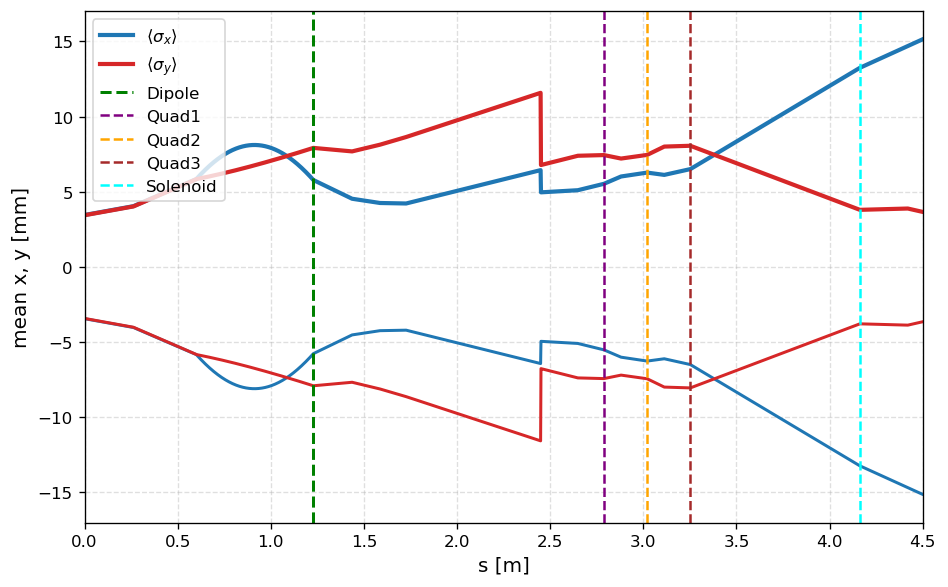

In [87]:
#M1 = B1.get_phase_space('%x %xp %y %yp')
#
#x  = M1[:,0]
#xp = M1[:,1]
#y  = M1[:,2]
#yp = M1[:,3]
#
#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y,yp,"y [mm]", "y' [rad]")

T = lebt.get_transport_table('%S %sigma_x %sigma_y')

s  = T[:, 0]
mx = T[:, 1]
my = T[:, 2]


elements_mm = [260, 2.5, 337.5, 628.318, 208, 150, 140, 722, 2, 2, 2, 194, 
               140, 92, 140, 92, 140, 910.1, 257.4, 139.3]

elements_m = np.array(elements_mm)/1000.0

s_positions = np.cumsum(elements_m)


dipole_pos = s_positions[3] #+ elements_m[3]/2   
quad1_pos  = s_positions[12] #+ elements_m[12]/2 
quad2_pos  = s_positions[14] #+ elements_m[14]/2
quad3_pos  = s_positions[16] #+ elements_m[16]/2 
solenoid_pos = s_positions[17] #+ elements_m[17]/2

plt.figure(figsize=(8, 5), dpi=120)

color_x = 'tab:blue'
color_y = 'tab:red'

plt.plot(s,  mx,  color=color_x, linewidth=2.5, linestyle='-',  label=r'$\langle \sigma_x \rangle$')
plt.plot(s, -mx,  color=color_x, linewidth=1.8, linestyle='-')
plt.plot(s,  my,  color=color_y, linewidth=2.5, linestyle='-',  label=r'$\langle \sigma_y \rangle$')
plt.plot(s, -my,  color=color_y, linewidth=1.8, linestyle='-',)

plt.axvline(dipole_pos, color='green', linestyle='--', linewidth=1.8, label='Dipole')
plt.axvline(quad1_pos, color='purple', linestyle='--', linewidth=1.5, label='Quad1')
plt.axvline(quad2_pos, color='orange', linestyle='--', linewidth=1.5, label='Quad2')
plt.axvline(quad3_pos, color='brown', linestyle='--', linewidth=1.5, label='Quad3')
plt.axvline(solenoid_pos, color='cyan', linestyle='--', linewidth=1.5, label='Solenoid')

plt.xlabel('s [m]', fontsize=12)
plt.ylabel('mean x, y [mm]', fontsize=12)
plt.xlim(0, 4.5) 

plt.legend(loc='upper left') 

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

